# 📊 FinDataMining
Notebook 02: **Transformación de Datos**

---

## Preliminares

In [1]:
import pandas as pd
import numpy as np
from src.config import data_folder, raw_data_file
%load_ext autoreload
%autoreload 2
from src.clean_transform import corregir_anomalias, imputar_info
from src.transform import *

In [2]:
# Abrir archivo raw_data
df = pd.read_parquet(raw_data_file)

# Se asegura el ordenamiento por fecha
df = df.sort_values(by='Date').reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37481 entries, 0 to 37480
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         37481 non-null  datetime64[ns]
 1   Ticker                       37481 non-null  object        
 2   Close                        37481 non-null  float64       
 3   Open                         37481 non-null  float64       
 4   Volume                       37481 non-null  float64       
 5   BasicAverageShares           37421 non-null  float64       
 6   CapitalExpenditure           36639 non-null  float64       
 7   CashAndCashEquivalents       37407 non-null  float64       
 8   CurrentAssets                35559 non-null  float64       
 9   CurrentDebt                  29544 non-null  float64       
 10  CurrentLiabilities           35564 non-null  float64       
 11  DepreciationAndAmortization  20544 non-nu

## Limpieza de Datos

Limpiar cadenas en Industry y Sector: 
* sin espacios iniciales ni finales.
* primer letra en mayúscula.
* se reemplaza el símbolo '&' por 'And'.

Además se convierten a variables de tipo "Category"

In [3]:
df = limpiar_industry_y_sector(df)

# Ver cambios
df[['Industry', 'Sector']].head()

,Industry,Sector
0,Entertainment,Communication Services
1,Industrial Distribution,Industrials
2,Personal Services,Consumer Cyclical
3,Grocery Stores,Consumer Defensive
4,Industrial Distribution,Industrials


In [4]:
# Valores únicos en Sector
df['Sector'].value_counts()

Sector
Consumer Cyclical         7597
Industrials               7592
Technology                5972
Healthcare                3633
Financial Services        3010
Consumer Defensive        2628
Energy                    2178
Basic Materials           1983
Communication Services    1521
Real Estate                753
Utilities                  614
Name: count, dtype: int64

In [5]:
# Valores únicos en Industry
df['Industry'].value_counts()

Industry
Specialty Industrial Machinery           1235
Software Application                      912
Semiconductors                            897
Engineering And Construction              870
Restaurants                               827
                                         ... 
Marine Shipping                            68
Utilities Diversified                      68
Reit Hotel And Motel                       68
Utilities Independent Power Producers      68
Coking Coal                                64
Name: count, Length: 117, dtype: int64

* Para mejorar la visualización de los datos, se expresan las columnas financieras y volumen en millones:

In [6]:
df_clean = columnas_en_millones(df)

### Corrección de anomalías

#### Error de importes en Balance General
Se analiza el siguiente registro, el cual muestra valores extremadamente elevados en el Balance:

In [7]:
# Caso 1: Error de importes en el Galance General
condicion_1 = df_clean[(df_clean['Ticker'] == 'IIIN') & (df_clean['Date'] == '2021-12-01')]

# Mostrar el registro
print(condicion_1.T)

                                            7288
Date                         2021-12-01 00:00:00
Ticker                                      IIIN
Close                                  31.841919
Open                                   32.969703
Volume                                    2.4059
BasicAverageShares                        19.344
CapitalExpenditure                        -3.819
CashAndCashEquivalents                   89884.0
CurrentAssets                           246906.0
CurrentDebt                                  NaN
CurrentLiabilities                       88672.0
DepreciationAndAmortization                  NaN
EBITDA                                       NaN
FinancialsSource                          simFin
FinancingCashFlow                         -0.438
FreeCashFlow                                 NaN
GrossProfit                               39.919
InvestingCashFlow                         -3.921
LongTermDebt                                 NaN
NetIncome           

* Se observa una desconexión en los valores del Balance General, están multiplicados por 1.000.
* El caso se detecto ya que arrojaba valores extremos en las métricas.

Se corrigirá dividiendo las columnas afectadas por 1.000.

#### Anomalías de signo: 

Las siguientes variables no pueden ser negativas:
* `TotalRevenue`
* `CurrentDebt`
* `LongTermDebt`
* `DepreciationAndAmortization`

In [8]:
# Caso 2:  TotalRevenue negativo
condicion_2 = df_clean['TotalRevenue'] < 0

# Mostrar los registros
cols_a_visualizar_2 = ['Ticker', 'Date', 'TotalRevenue', 'OperatingIncome']
anomalias = df_clean.loc[condicion_2, cols_a_visualizar_2]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

      Ticker       Date  TotalRevenue  OperatingIncome
2173     ALB 2021-03-01   -1790.31392      -114.758843
2370    AVNT 2021-03-01     -30.20000       -12.700000
2386     XPO 2021-03-01   -1093.00000        14.000000
2597     EXE 2021-04-01   -3731.00000       205.000000
2668    AVNT 2021-04-01     -30.20000       -12.700000
...      ...        ...           ...              ...
27332   OTIS 2025-01-01   -3490.00000      -538.000000
28170   OTIS 2025-02-01   -3490.00000      -538.000000
28495    MAR 2025-03-01  -12053.00000       804.000000
28932    MAR 2025-04-01  -12053.00000       804.000000
29574    MAR 2025-05-01  -12053.00000       804.000000

[80 rows x 4 columns]
Cantidad de casos: 80


* No se puede concluir que se traten de alteraciones de signo en el parseo de datos de simFin. Se observan casos en los que el valor absoluto de `TotalRevenue` es mayor que `OperatingIncome`, es imposible que los resultados sean mayores que las ventas.

Se opta por asignar todos estos valores anómalos a NaN.

In [9]:
# Caso 3:  Deuda negativa
condicion_3 = (df_clean['CurrentDebt'] < 0) | (df_clean['LongTermDebt'] < 0)

# Ver registros
cols_a_visualizar_3 = ['Ticker', 'Date', 'TotalDebt', 'CurrentDebt', 'LongTermDebt']
anomalias = df_clean.loc[condicion_3, cols_a_visualizar_3]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

      Ticker       Date  TotalDebt  CurrentDebt  LongTermDebt
12225    IEP 2022-09-01        NaN     -746.000      7134.000
12812    IEP 2022-10-01        NaN     -746.000      7134.000
12984    IEP 2022-11-01        NaN     -746.000      7134.000
13716    IEP 2022-12-01        NaN     -745.000      7127.000
14029    IEP 2023-01-01        NaN     -745.000      7127.000
14662    IEP 2023-02-01        NaN     -745.000      7127.000
15399    IEP 2023-03-01        NaN     -745.000      7981.000
15877    IEP 2023-04-01        NaN     -745.000      7981.000
16306    IEP 2023-05-01        NaN     -745.000      7981.000
17168    IEP 2023-06-01        NaN     -745.000      7755.000
21811   STLD 2024-03-01        NaN      459.987     -3286.537
22386   STLD 2024-04-01        NaN      459.987     -3286.537
22738   STLD 2024-05-01        NaN      459.987     -3286.537
23726   STLD 2024-06-01        NaN      425.696     -3570.028
24347   STLD 2024-07-01        NaN      425.696     -3570.028
24389   

* Se observan en las filas que TotalDebt es NaN, se infiere que la API intenta sumar y al encontrar signo negativo arruina la ecuación, devolviendo nulos.
* Al faltar TotalDebt, no se puede confirmar que se traten de errores de signo.

Se asignan dichos valores a NaN.

#### Negativos en `DepreciationAndAmortization`: 

Se analizan los casos separando los registros según provengan de `yfinance` o de `simFin`:

In [10]:
# Caso 4:  Depreciación y Amortización negativa de yfinance
condicion_4 = (df_clean['DepreciationAndAmortization'] < 0) & (df_clean['FinancialsSource']=='yfinance')

# Ver registros
cols_a_visualizar_4 = ['Ticker', 'Date', 'DepreciationAndAmortization', 'EBITDA', 'OperatingIncome', 'FinancialsSource', 'Sector']
anomalias = df_clean.loc[condicion_4, cols_a_visualizar_4]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

      Ticker       Date  DepreciationAndAmortization    EBITDA  \
30967    WRB 2025-08-01                      -13.969       NaN   
30971    EXE 2025-08-01                     -711.000  2057.000   
30981    AAL 2025-08-01                     -468.000  1271.000   
31052    RRC 2025-08-01                      -90.559   420.352   
31081   LBRT 2025-08-01                     -127.742   234.681   
...      ...        ...                          ...       ...   
36466    GME 2026-06-01                       -0.300       NaN   
36474    RNR 2026-06-01                      -24.360       NaN   
36822    WRB 2026-06-01                      -15.466       NaN   
37251    WRB 2026-07-01                      -15.466       NaN   
37349    RNR 2026-07-01                      -24.360       NaN   

       OperatingIncome FinancialsSource              Sector  
30967          696.697         yfinance  Financial Services  
30971         1314.000         yfinance              Energy  
30981         1182.00

* Ya que son unos pocos valores recientes y la D&A no es un gasto volátil (es la es la distribución contable de un costo de capital a lo largo de los años), se decide asignarlos a NaN para luego ser imputados por medias móviles.

In [11]:
# # Caso 5: Depreciación y Amortización negativa de simFin
condicion_5 = (df_clean['DepreciationAndAmortization'] < 0) & (df_clean['FinancialsSource']=='simFin')

# Ver registros
anomalias = df_clean.loc[condicion_5, cols_a_visualizar_4] # mismas columnas que el caso anterior
print(anomalias)
print("Cantidad de casos:", len(anomalias))

      Ticker       Date  DepreciationAndAmortization  EBITDA  OperatingIncome  \
7       SNPS 2020-09-01                       -9.931     NaN          208.621   
18        HD 2020-09-01                     -519.000     NaN         6067.000   
20        DY 2020-09-01                      -44.129     NaN           54.482   
24       LOW 2020-09-01                     -327.000     NaN         3957.000   
26      BURL 2020-09-01                      -54.404     NaN          -81.224   
...      ...        ...                          ...     ...              ...   
31848     KR 2025-09-01                    -1051.000     NaN         1322.000   
31871    KMX 2025-09-01                      -65.739     NaN          168.241   
31891   SNPS 2025-09-01                       -3.996     NaN          376.426   
31964    JBL 2025-09-01                      -17.000     NaN          383.000   
32203    WGO 2025-10-01                       -5.500     NaN           30.200   

      FinancialsSource     

* `simFin` utiliza signo negativo para esta columna, lo cual es incorrecto. 

Dichos valores serán convertidos a positivos.

In [12]:
# Se aplican los cambios mencionados
df_clean = corregir_anomalias(df_clean)

## Tratamiento Inicial de Missings

Se realiza la imputación sobre las variables originales de los Estados Financieros.

In [13]:
# Ver incidencia de missings
mostrar_missings(df_clean)

EBITDA                         0.944665
TotalDebt                      0.942104
FreeCashFlow                   0.941597
DepreciationAndAmortization    0.453830
DateAdded                      0.439343
CurrentDebt                    0.212027
GrossProfit                    0.074171
LongTermDebt                   0.057709
TotalNoncurrentLiabilities     0.052560
CurrentAssets                  0.051279
CurrentLiabilities             0.051146
CapitalExpenditure             0.022465
OperatingIncome                0.006590
TotalRevenue                   0.003015
CashAndCashEquivalents         0.001974
BasicAverageShares             0.001601
OperatingCashFlow              0.000987
FinancingCashFlow              0.000960
NetIncome                      0.000880
InvestingCashFlow              0.000720
StockholdersEquity             0.000293
TotalAssets                    0.000160
TotalLiabilities               0.000160
dtype: float64

Si llegasen a quedar datos de Sector e Industry perdidos (a veces falla la descarga), se pueden volver a asignar desde aquí para no repetir todo el flujo de extracción:

In [ ]:
#df_clean = recuperar_info(df_clean)

No se encontraron valores perdidos de Sectores/Industrias.


Se pueden imputar manualmente casos persistentes completando los datos dentro de la función imputar_info del módulo `clean_transform`:

In [ ]:
# df_clean = imputar_info(df_clean)

* Se imputan parte de los NaNs en Variables Financieras antes de calcular métricas, 
mediante las relaciones contables entre ellas:

In [15]:
df_fin_imputed = imputar_equivalencias_financieras(df_clean)
mostrar_missings(df_fin_imputed)

DateAdded                     0.439343
GrossProfit                   0.074171
LongTermDebt                  0.043729
TotalDebt                     0.043729
CurrentDebt                   0.043729
CapitalExpenditure            0.022465
FreeCashFlow                  0.021531
OperatingIncome               0.006590
EBITDA                        0.006590
TotalRevenue                  0.003015
CashAndCashEquivalents        0.001974
BasicAverageShares            0.001601
OperatingCashFlow             0.000987
FinancingCashFlow             0.000960
NetIncome                     0.000880
InvestingCashFlow             0.000720
StockholdersEquity            0.000293
CurrentAssets                 0.000160
CurrentLiabilities            0.000160
TotalAssets                   0.000160
TotalNoncurrentLiabilities    0.000160
TotalLiabilities              0.000160
dtype: float64

In [16]:
# Se imputan las columnas financieras, por su media o mediana móvil según sus asimetrías
df_num_imputed = imputar_numericas(df_fin_imputed)
mostrar_missings(df_num_imputed)

DateAdded                     0.439343
GrossProfit                   0.071556
LongTermDebt                  0.037192
TotalDebt                     0.037192
CurrentDebt                   0.037192
CapitalExpenditure            0.020650
FreeCashFlow                  0.017395
OperatingIncome               0.004269
EBITDA                        0.004269
CashAndCashEquivalents        0.001788
BasicAverageShares            0.001334
TotalRevenue                  0.000987
NetIncome                     0.000880
OperatingCashFlow             0.000720
FinancingCashFlow             0.000694
InvestingCashFlow             0.000614
StockholdersEquity            0.000160
CurrentAssets                 0.000107
CurrentLiabilities            0.000107
TotalAssets                   0.000107
TotalNoncurrentLiabilities    0.000107
TotalLiabilities              0.000107
dtype: float64

Se remueven los Missings remanentes en columnas numéricas relevantes, es decir excluyendo las siguientes columnas que no se utilizan en el pipeline actual:
- `GrossProfit`
- `FinancingCashFlow`
- `InvestingCashFlow`

Es necesario que no hayan valores perdidos antes de calcular los valores TTM. 

In [17]:
cols_no_relevantes = ['GrossProfit', 'FinancingCashFlow', 'InvestingCashFlow']
df_imputed = quitar_nulos_relevantes(df_num_imputed, cols_no_relevantes)
mostrar_missings(df_imputed)

DateAdded            0.440389
GrossProfit          0.054857
FinancingCashFlow    0.000085
dtype: float64

In [18]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35128 entries, 7 to 37480
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         35128 non-null  datetime64[ns]
 1   Ticker                       35128 non-null  object        
 2   Close                        35128 non-null  float64       
 3   Open                         35128 non-null  float64       
 4   Volume                       35128 non-null  float64       
 5   BasicAverageShares           35128 non-null  float64       
 6   CapitalExpenditure           35128 non-null  float64       
 7   CashAndCashEquivalents       35128 non-null  float64       
 8   CurrentAssets                35128 non-null  float64       
 9   CurrentDebt                  35128 non-null  float64       
 10  CurrentLiabilities           35128 non-null  float64       
 11  DepreciationAndAmortization  35128 non-null  f

## Feature Engineering

* Se convierten las variables de flujo trimestrales a valores TTM (ventana móvil de 12 meses):

In [19]:
df_with_ttm = transformar_flujos_a_ttm(df_imputed)
mostrar_missings(df_with_ttm)

DateAdded                          0.440389
GrossProfit_TTM                    0.081417
TotalRevenue_TTM                   0.030802
OperatingIncome_TTM                0.030802
NetIncome_TTM                      0.030802
EBITDA_TTM                         0.030802
BasicAverageShares_TTM             0.030802
OperatingCashFlow_TTM              0.030802
InvestingCashFlow_TTM              0.030802
FinancingCashFlow_TTM              0.030802
FreeCashFlow_TTM                   0.030802
CapitalExpenditure_TTM             0.030802
DepreciationAndAmortization_TTM    0.030802
dtype: float64

* Se reemplaza `DateAdded` por nueva feature `YearsSinceAdded`, donde los valores missing corresponden a cero años (no pertenecen al índice S&P 500):

In [20]:
df_with_years_since_added = crear_years_since_added(df_with_ttm)

* Calcular métricas financieras y ratios de valuación:

In [21]:
df_with_metrics = calcular_metricas(df_with_years_since_added)
mostrar_missings(df_with_metrics)

GrossProfit_TTM                    0.081417
DebtToEquity                       0.069460
ReturnOnEquity                     0.034303
TotalRevenue_TTM                   0.030802
OperatingIncome_TTM                0.030802
BasicAverageShares_TTM             0.030802
OperatingCashFlow_TTM              0.030802
NetIncome_TTM                      0.030802
EBITDA_TTM                         0.030802
FinancingCashFlow_TTM              0.030802
InvestingCashFlow_TTM              0.030802
FreeCashFlow_TTM                   0.030802
CapitalExpenditure_TTM             0.030802
EnterpriseValue                    0.030802
EarningsYield                      0.030802
DepreciationAndAmortization_TTM    0.030802
MarketCap                          0.030802
BookToMarket                       0.030802
EbitdaYield                        0.030802
ProfitMargins                      0.030802
OperatingMargins                   0.030802
ReturnOnAssets                     0.030802
NetDebtToEbitda                 

Convertir `volume`:
* Se reemplaza el volumen total trimestral por su promedio diario (AverageDailyVolume), ya que es el valor estándar utilizado en finanzas. El cálculo es aproximado, dividiendo los valores de `Volume` entre 21 (252 días hábiles entre 12).
* Se aplica lag de 1 período a AverageDailyVolume para evitar Data Leakage.

In [22]:
df_volume_converted = convertir_volumen_a_adv(df_with_metrics)
columnas_lag1 = ['AverageDailyVolume']
df_volume_converted = calcular_lag(df_volume_converted, columnas_lag1, months=1)

Cálculo de los crecimientos y las aceleraciones:
* Primero se calculan las tasas de crecimiento para las variables indicadas en "crecimiento_cols", incluyendo las variaciones anuales (YoY) y trimestrales (QoQ) .
* Luego se calculan las aceleraciones (Momento - Tendencia), definidas como la diferencia entre la tasa de cambio de corto plazo (QoQ) y la de largo plazo (YoY). 

In [23]:
# Calcular crecimientos
crecimiento_cols = [
    'TotalRevenue_TTM',
    'EBITDA_TTM',
    'FreeCashFlow_TTM',
    'CapitalExpenditure_TTM',
    'AverageDailyVolume_Lag1'
]
df_with_growth = calcular_crecimientos(df_volume_converted, crecimiento_cols)
mostrar_missings(df_with_growth)

TotalRevenue_TTM_YoY               0.214131
CapitalExpenditure_TTM_YoY         0.214131
FreeCashFlow_TTM_YoY               0.214131
EBITDA_TTM_YoY                     0.214131
AverageDailyVolume_Lag1_YoY        0.184354
GrossProfit_TTM                    0.081417
CapitalExpenditure_TTM_QoQ         0.077033
TotalRevenue_TTM_QoQ               0.077004
FreeCashFlow_TTM_QoQ               0.077004
EBITDA_TTM_QoQ                     0.077004
DebtToEquity                       0.069460
AverageDailyVolume_Lag1_QoQ        0.046231
ReturnOnEquity                     0.034303
NetIncome_TTM                      0.030802
TotalRevenue_TTM                   0.030802
OperatingIncome_TTM                0.030802
EBITDA_TTM                         0.030802
BasicAverageShares_TTM             0.030802
OperatingCashFlow_TTM              0.030802
InvestingCashFlow_TTM              0.030802
ReturnOnAssets                     0.030802
ProfitMargins                      0.030802
OperatingMargins                

Antes de calcular las aceleraciones, se tratan los valores nulos en los valores iniciales de las columnas de crecimiento. Se imputan con las tasas de inflación promedio históricas de EE.UU. (asumiendo crecimiento neutral) y se crean variables flag `IsMissing`: 

In [24]:
df_growth_imputed = imputar_crecimientos(df_with_growth, crecimiento_cols)
mostrar_missings(df_growth_imputed)

GrossProfit_TTM                    0.081417
DebtToEquity                       0.069460
ReturnOnEquity                     0.034303
NetIncome_TTM                      0.030802
OperatingIncome_TTM                0.030802
BasicAverageShares_TTM             0.030802
OperatingCashFlow_TTM              0.030802
InvestingCashFlow_TTM              0.030802
EBITDA_TTM                         0.030802
TotalRevenue_TTM                   0.030802
FreeCashFlow_TTM                   0.030802
FinancingCashFlow_TTM              0.030802
CapitalExpenditure_TTM             0.030802
DepreciationAndAmortization_TTM    0.030802
EarningsYield                      0.030802
EbitdaYield                        0.030802
MarketCap                          0.030802
EnterpriseValue                    0.030802
OperatingMargins                   0.030802
BookToMarket                       0.030802
ReturnOnAssets                     0.030802
ProfitMargins                      0.030802
NetDebtToEbitda                 

* Se calculan las aceleraciones, definidas como la tasa de crecimiento de corto plazo (QoQ) menos la de largo (YoY):

In [25]:
df_with_acc = calcular_aceleraciones(df_growth_imputed, crecimiento_cols)

* Se calculan los retornos mensuales, completando missings con cero (valor neutral). Luego se calculan la varianza del activo y la covarianza con el mercado para obtener el coeficiente Beta de corto plazo (ShortTermBeta sobre una ventana de 12 meses):

In [26]:
# Se abre el fichero de precios del Índice del Mercado para calcular las covarianzas
df_index = pd.read_parquet(f"{data_folder}/market_index.parquet")

df_with_returns = calcular_retornos_y_betas(df_with_acc, df_index)
mostrar_missings(df_with_returns)

GrossProfit_TTM                    0.081417
DebtToEquity                       0.069460
ShortTermBeta                      0.037662
ReturnOnEquity                     0.034303
NetIncome_TTM                      0.030802
BasicAverageShares_TTM             0.030802
OperatingCashFlow_TTM              0.030802
InvestingCashFlow_TTM              0.030802
EBITDA_TTM                         0.030802
TotalRevenue_TTM                   0.030802
OperatingIncome_TTM                0.030802
CapitalExpenditure_TTM             0.030802
FreeCashFlow_TTM                   0.030802
FinancingCashFlow_TTM              0.030802
DepreciationAndAmortization_TTM    0.030802
EbitdaYield                        0.030802
MarketCap                          0.030802
EnterpriseValue                    0.030802
EarningsYield                      0.030802
ProfitMargins                      0.030802
OperatingMargins                   0.030802
BookToMarket                       0.030802
ReturnOnAssets                  

* Se calculan tamaños relativos: RelativeAssets y RelativeRevenue

In [27]:
df_with_features = calcular_relative_size(df_with_returns)
mostrar_missings(df_with_features)

GrossProfit_TTM                    0.081417
DebtToEquity                       0.069460
ShortTermBeta                      0.037662
ReturnOnEquity                     0.034303
EBITDA_TTM                         0.030802
BasicAverageShares_TTM             0.030802
OperatingCashFlow_TTM              0.030802
InvestingCashFlow_TTM              0.030802
FinancingCashFlow_TTM              0.030802
TotalRevenue_TTM                   0.030802
OperatingIncome_TTM                0.030802
NetIncome_TTM                      0.030802
DepreciationAndAmortization_TTM    0.030802
CapitalExpenditure_TTM             0.030802
FreeCashFlow_TTM                   0.030802
MarketCap                          0.030802
BookToMarket                       0.030802
EnterpriseValue                    0.030802
EarningsYield                      0.030802
EbitdaYield                        0.030802
ReturnOnAssets                     0.030802
ProfitMargins                      0.030802
OperatingMargins                

## Tratamiento Final de Missings

Se gestionan los valores perdidos remanentes en las variables nuevas.

In [28]:
# Se aplica la imputación de medias móviles sobre las nuevas variables
df_final_num_imputed = imputar_numericas(df_with_features)
mostrar_missings(df_final_num_imputed)

GrossProfit_TTM                    0.080563
DebtToEquity                       0.065105
ShortTermBeta                      0.037662
ReturnOnEquity                     0.033364
EBITDA_TTM                         0.030802
BasicAverageShares_TTM             0.030802
OperatingCashFlow_TTM              0.030802
InvestingCashFlow_TTM              0.030802
FinancingCashFlow_TTM              0.030802
TotalRevenue_TTM                   0.030802
OperatingIncome_TTM                0.030802
NetIncome_TTM                      0.030802
DepreciationAndAmortization_TTM    0.030802
CapitalExpenditure_TTM             0.030802
FreeCashFlow_TTM                   0.030802
MarketCap                          0.030802
BookToMarket                       0.030802
EnterpriseValue                    0.030802
EarningsYield                      0.030802
EbitdaYield                        0.030802
ReturnOnAssets                     0.030802
ProfitMargins                      0.030802
OperatingMargins                

* Se eliminan missings remanentes:

In [29]:
cols_no_relevantes = [
    'GrossProfit_TTM',
    ]
df_final_imputed = quitar_nulos_relevantes(df_final_num_imputed, cols_no_relevantes)
mostrar_missings(df_final_imputed)

GrossProfit_TTM    0.053679
dtype: float64

## Análisis Exploratorio de Datos

In [30]:
df_final_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31502 entries, 4 to 35127
Data columns (total 75 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Date                                   31502 non-null  datetime64[ns]
 1   Ticker                                 31502 non-null  object        
 2   Close                                  31502 non-null  float64       
 3   Open                                   31502 non-null  float64       
 4   CashAndCashEquivalents                 31502 non-null  float64       
 5   CurrentAssets                          31502 non-null  float64       
 6   CurrentDebt                            31502 non-null  float64       
 7   CurrentLiabilities                     31502 non-null  float64       
 8   FinancialsSource                       31502 non-null  object        
 9   LongTermDebt                           31502 non-null  float64    

In [31]:
# Analizar la distribución de una columna específica
df_final_imputed['ShortTermBeta'].describe().round(4).T

count    31502.0000
mean         0.9172
std          1.0134
min        -41.5568
25%          0.3738
50%          0.8996
75%          1.3909
max         12.9683
Name: ShortTermBeta, dtype: float64

In [32]:
# Coeficientes de asimetría
df_final_imputed.select_dtypes(include="number").skew().sort_values(ascending=False)

FcfToEbitda             169.105880
BookToMarket            101.282282
QuarterlyReturn_Lag1     46.572923
TotalRevenue_TTM_QoQ     46.200386
CapExToRevenue           43.179362
                           ...    
ReturnOnEquity          -42.895862
OperatingMargins        -44.229987
ProfitMargins           -44.873585
EarningsYield           -56.562039
NetDebtToEbitda        -158.090608
Length: 70, dtype: float64

In [33]:
# Analizar extremos
df_min = df_final_imputed.loc[df_final_imputed['ShortTermBeta'].idxmin()]
df_min

Date                      2022-02-01 00:00:00
Ticker                                    GME
Close                               30.834999
Open                                28.252501
CashAndCashEquivalents                 1413.0
                                 ...         
QuarterlyReturn_Lag1                -0.251605
ShortTermBeta                      -41.556763
ReturnIsMissing_Lag1                      0.0
RelativeAssets                       0.000195
RelativeRevenue                      0.000526
Name: 13735, Length: 75, dtype: object

Cont


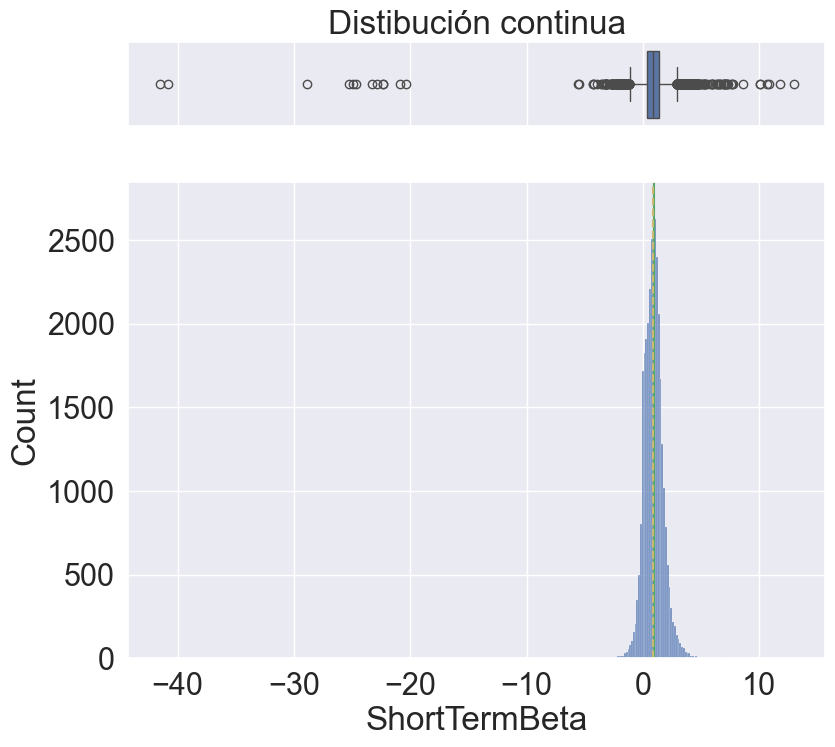

In [34]:
# Graficar
columna_a_graficar = 'ShortTermBeta' # indicar columna para el gráfico
plot(df_final_imputed[columna_a_graficar])

## Transformaciones

* Transformaciones logarítmicas:

In [35]:
columnas_log = [ 
    'CapExToRevenue',
    'DebtToEquity',
    'MarketCap'
    ]

df_log_transformed = transformar_log(
    df_final_imputed, 
    columnas_log, 
    calculo_1p=True
    )

print("### Coeficientes de asimetría antes y después de transformar: ###")
for col in columnas_log:
    print(f'  - {col}:', df_final_imputed[col].skew(), '->', df_log_transformed[f'{col}_Log1p'].skew())

### Coeficientes de asimetría antes y después de transformar: ###
  - CapExToRevenue: 43.1793622304481 -> 15.244547365014427
  - DebtToEquity: 34.67042778297526 -> 2.6795552282041295
  - MarketCap: 9.496513163620461 -> -0.05336330449527944


* Transformaciones Yeo-Johnson (trata columnas que puedan tener valores negativos):

In [36]:
columnas_yeo = [ 
    'EnterpriseValue',
    ]

df_transformed = transformar_yeo_johnson(
    df_log_transformed, 
    columnas_yeo
    )

print("### Coeficientes de asimetría antes y después de transformar: ###")
for col in columnas_yeo:
    print(f'  - {col}:', df_final_imputed[col].skew(), '->', df_transformed[f'{col}_YeoTransformed'].skew())

### Coeficientes de asimetría antes y después de transformar: ###
  - EnterpriseValue: 9.272905558563107 -> 1.5207616481513588


## Tratamiento de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [37]:
# Definir columnas que saltean la "winsorización"
cols_fin_clean = obtener_cols_financieras(incluirTTM=True)

columnas_intactas = cols_fin_clean + [
    # Variables de precio y ratios
    'Close',
    'Open',    
    'EarningsYield',
    'EbitdaYield',
    'BookToMarket',
    # Otras
    'Date', 
    'Ticker'   
    ]

# Separar el dataset
df_passthrough = df_transformed[columnas_intactas].copy()
df_transformed_features = df_transformed.drop(columns=columnas_intactas)

In [38]:
df_transformed_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31502 entries, 4 to 35127
Data columns (total 46 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   FinancialsSource                       31502 non-null  object  
 1   Sector                                 31502 non-null  category
 2   Industry                               31502 non-null  category
 3   YearsSinceAdded                        31502 non-null  float64 
 4   OperatingMargins                       31502 non-null  float64 
 5   ProfitMargins                          31502 non-null  float64 
 6   ReturnOnAssets                         31502 non-null  float64 
 7   ReturnOnEquity                         31502 non-null  float64 
 8   CurrentRatio                           31502 non-null  float64 
 9   NetDebtToEbitda                        31502 non-null  float64 
 10  FcfToEbitda                            31502 non-null  float64 

In [39]:
# Outliers
df_cont_transformed = df_transformed_features.select_dtypes(include="number")
df_winsor = df_cont_transformed.apply(lambda x: gestiona_outliers(x, clas='winsor'))

In [40]:
# Coeficientes de asimetría luego de winsorizar
df_winsor.skew().sort_values(ascending=False)

ReturnIsMissing_Lag1                     23.043104
AverageDailyVolume_Lag1_QoQ_IsMissing    10.828490
TotalRevenue_TTM_QoQ_IsMissing            4.781608
EBITDA_TTM_QoQ_IsMissing                  4.781608
FreeCashFlow_TTM_QoQ_IsMissing            4.781608
CapitalExpenditure_TTM_QoQ_IsMissing      4.779400
AverageDailyVolume_Lag1_YoY_IsMissing     1.934351
RelativeAssets                            1.716093
AverageDailyVolume_Lag1                   1.714543
RelativeRevenue                           1.682333
EnterpriseValue_YeoTransformed            1.674572
CapExToRevenue_Log1p                      1.640436
FreeCashFlow_TTM_YoY_IsMissing            1.631485
TotalRevenue_TTM_YoY_IsMissing            1.631485
CapitalExpenditure_TTM_YoY_IsMissing      1.631485
EBITDA_TTM_YoY_IsMissing                  1.631485
DebtToEquity_Log1p                        1.551059
CurrentRatio                              1.511512
YearsSinceAdded                           1.498893
AverageDailyVolume_Lag1_QoQ    

Cont


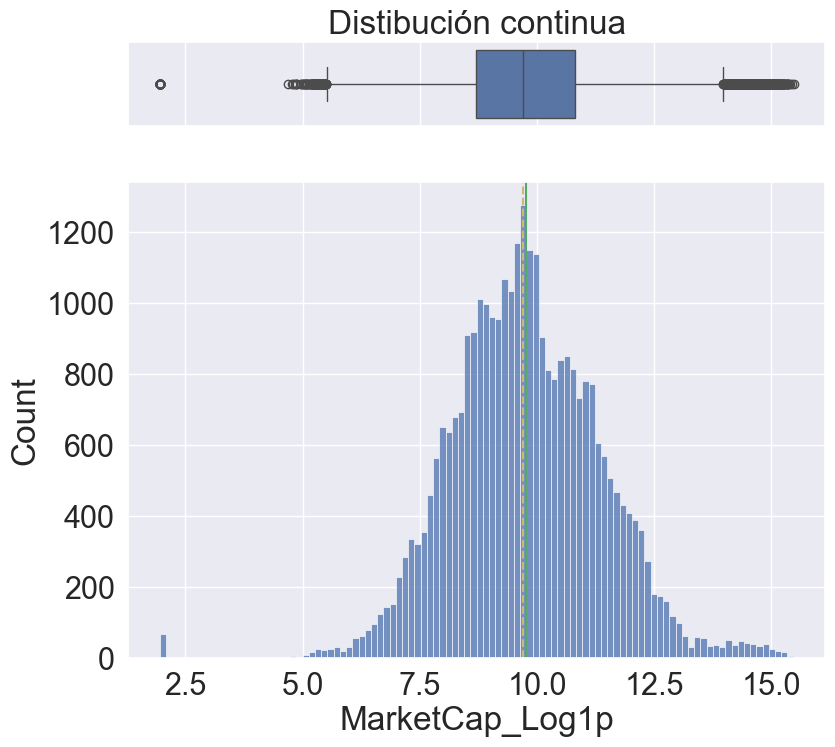

In [41]:
# Visualizar cambios
columna_a_graficar = 'MarketCap_Log1p' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [42]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
YearsSinceAdded,31502.0,14.392642,19.929735,0.000000e+00,0.000000,5.000000,23.000000,69.000000
OperatingMargins,31502.0,0.141804,0.131205,-3.644850e-01,0.061368,0.124640,0.203180,0.629332
ProfitMargins,31502.0,0.092903,0.119095,-3.073560e-01,0.032503,0.081867,0.145784,0.487657
ReturnOnAssets,31502.0,0.188435,0.216094,-5.503380e-01,0.077670,0.167944,0.286896,0.915268
ReturnOnEquity,31502.0,0.579977,0.774153,-1.625241e+00,0.230980,0.469184,0.849463,2.705365
CurrentRatio,31502.0,1.733387,0.973652,8.650500e-02,1.084985,1.471137,2.130231,5.266517
NetDebtToEbitda,31502.0,0.825063,1.120785,-2.888239e+00,0.232701,0.680831,1.271282,4.387067
FcfToEbitda,31502.0,0.610896,0.648902,-1.231027e+00,0.347355,0.617942,0.872449,2.451314
AverageDailyVolume_Lag1,31502.0,3.256072,3.904042,0.000000e+00,0.698600,1.601260,4.049426,14.103381
TotalRevenue_TTM_YoY,31502.0,0.070967,0.135766,-3.134031e-01,0.012222,0.035381,0.120275,0.444498


## Concatenación Final y Almacenamiento

In [43]:
df_non_numeric_transformed = df_transformed_features.select_dtypes(exclude='number')
# Se unen variables contínuas transformadas y variables no numéricas
df_combined = pd.concat([df_non_numeric_transformed, df_winsor], axis=1)

# Unir con las columnas que fueron salteadas
df_final = pd.concat([df_passthrough, df_combined], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31502 entries, 4 to 35127
Data columns (total 75 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   CashAndCashEquivalents                 31502 non-null  float64       
 1   CurrentDebt                            31502 non-null  float64       
 2   LongTermDebt                           31502 non-null  float64       
 3   TotalDebt                              31502 non-null  float64       
 4   StockholdersEquity                     31502 non-null  float64       
 5   TotalAssets                            31502 non-null  float64       
 6   CurrentAssets                          31502 non-null  float64       
 7   CurrentLiabilities                     31502 non-null  float64       
 8   TotalNoncurrentLiabilities             31502 non-null  float64       
 9   TotalLiabilities                       31502 non-null  float64    

In [44]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")
print(f"Fichero 'clean_data.parquet' guardado en la carpeta {data_folder}")

Fichero 'clean_data.parquet' guardado en la carpeta data
